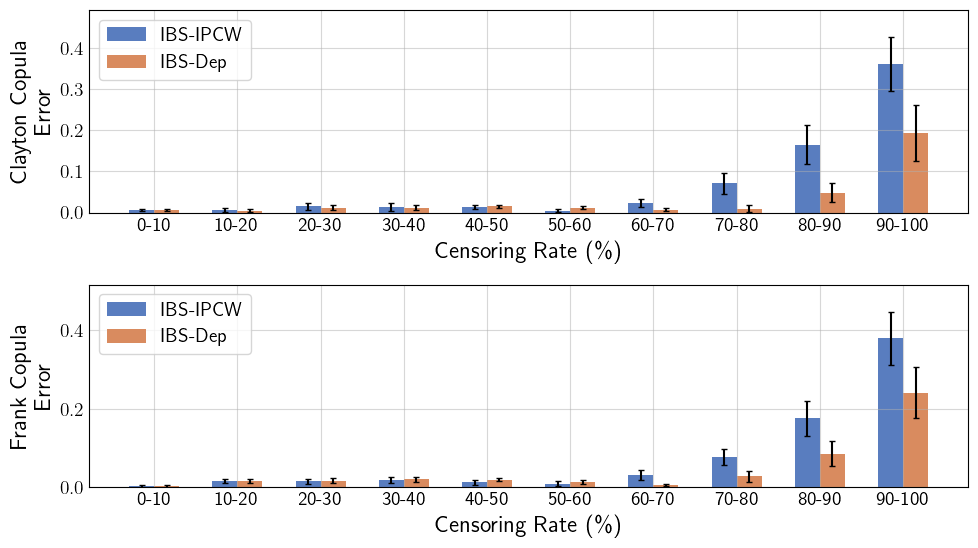

In [28]:
import numpy as np
import pandas as pd
import config as cfg
import seaborn as sns
from scipy.stats import zscore
from matplotlib import pyplot as plt

plt.style.use("default")
plt.rcParams.update({
    "axes.labelsize": "large",
    "axes.titlesize": "large",
    "font.size": 14.0,
    "legend.fontsize": "medium",
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsfonts} \usepackage{amstext} \usepackage{bm}"
})

filename = f"{cfg.RESULTS_DIR}/synthetic_results_censoring.csv"
df = pd.read_csv(filename)

error_columns = [
    ("err_ipcw", "err_dep_bguw", "IBS-IPCW", r"IBS-Dep")
]

df["censoring_bin"] = df["censoring_bin"].astype("string")

def _left_edge(s):
    try:
        return float(str(s).split("-")[0])
    except Exception:
        return np.inf

ordered_labels = sorted(df["censoring_bin"].unique().tolist(), key=_left_edge)
df["censoring_bin"] = pd.Categorical(df["censoring_bin"], categories=ordered_labels, ordered=True)

fig, axes = plt.subplots(2, 1, figsize=(10, 6))
axes = np.array(axes).reshape(2, 1)

copulas = ["clayton", "frank"]

for row_idx, copula in enumerate(copulas):
    df_copula = df[df["copula_name"] == copula]

    for i, (metric1, metric2, label1, label2) in enumerate(error_columns):
        ax = axes[row_idx, i]

        sigma_level = 1.0

        grouped = (
            df_copula
            .groupby("censoring_bin")[[metric1, metric2]]
            .agg(["mean", "std"])
        )
        grouped.columns = ["_".join(col) for col in grouped.columns]
        grouped = grouped.reset_index()

        # Force all bins to appear (even if empty)
        grouped = (
            grouped.set_index("censoring_bin")
                .reindex(ordered_labels)
                .reset_index()
        )

        plot_df = pd.DataFrame({
            "censoring_bin": pd.concat([grouped["censoring_bin"], grouped["censoring_bin"]], ignore_index=True),
            "Metric": [metric1]*len(grouped) + [metric2]*len(grouped),
            "Mean": pd.concat([grouped[f"{metric1}_mean"], grouped[f"{metric2}_mean"]], ignore_index=True),
            "Err": pd.concat([grouped[f"{metric1}_std"], grouped[f"{metric2}_std"]], ignore_index=True),
        })

        sns.barplot(
            data=plot_df,
            x="censoring_bin", y="Mean", hue="Metric",
            ax=ax,
            errorbar=None,
            palette="muted",
            alpha=1,
            linewidth=3,
            width=0.6
        )

        # Manual error bars (± SD)
        for metric_idx, metric in enumerate([metric1, metric2]):
            bars = ax.containers[metric_idx]
            err_vals = plot_df.loc[plot_df["Metric"] == metric, "Err"].values
            for bar, err in zip(bars, err_vals):
                if np.isnan(err):
                    continue
                x = bar.get_x() + bar.get_width() / 2
                y = bar.get_height()
                ax.errorbar(x, y, yerr=sigma_level * err, fmt="none", c="black", capsize=2)

        # Legend
        ax.legend_.remove()
        ax.legend(handles=ax.containers[:2], labels=[label1, label2], fontsize=14)

        # Labels
        ax.set_ylabel(f"{copula.capitalize()} Copula\nError")
        ax.set_xlabel("Censoring Rate (\%)")

        # Formatting
        y_min, y_max = ax.get_ylim()
        ax.set_ylim(0, y_max * 1.1)
        ax.grid(True, alpha=0.5)
        ax.tick_params(axis="y", which="both", length=0)
        ax.tick_params(axis="x", which="both", length=0)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(f"{cfg.PLOTS_DIR}/synthetic_censoring.pdf", format="pdf", bbox_inches="tight")
plt.show()